# Lesson 168 · Cross-database generalization

Default: portable CPU-only saved-evidence audit, Python 3 + NumPy. Embedded raw predictions, keys, receipts and diagrams; no downloads or cloud calls. Complete three contracts before interpreting the table. Fresh inference is a separate opt-in lane near the end.

<p class="route-lead">A model accepting a new schema is the beginning of a transfer experiment. The result becomes meaningful only after you specify what was unseen, what target information was allowed, and which databases the evidence covers.</p>

**Today’s win:** build a cross-database comparison you can defend. Spend **15 minutes** on the trace and explorer, then **30–45 minutes** on the notebook. The default notebook rescoring is CPU-only; fresh model inference has a separate executable lane.

[Student notebook](https://avistian.github.io/relational/labs/0168-cross-database-generalization.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0168-cross-database-generalization.html) · [Quick reference](https://avistian.github.io/relational/reference/cross-database-generalization.html) · [Full reproduction contract](https://avistian.github.io/relational/labs/l168-reproduction.md)

## 1 · The gap left by Lesson 167

[Lesson 167](https://avistian.github.io/relational/lessons/0167-tabular-to-relational-fm-transfer.html) separated the representation, pretrained prior and adaptation rule. Its 30 saved runs all concerned F1. Ten different support draws still share one database and one test population. To test a cross-database claim, change the **database**, preserve a defensible evaluation contract, and report each database separately.

Recall three prerequisites: a **support** row has a supplied label; a **query** row has a hidden target; a **schema** describes tables, columns and relationships. AUROC measures binary ranking: 0.5 is chance ranking, 1 is perfect ranking. Our mission is to test where relational modeling adds value, so the tabular comparator must receive the same available relational features and labels.

**Prediction to commit:** a frozen model receives 512 labeled target examples. Has it performed zero-shot prediction?

Commit your prediction: 512 target labels and zero gradient steps is few-shot ICL. Explain why before reading on.

## 2 · Ask “unseen in which sense?”

> **In plain terms.** Repeating a test with new examples from the same database asks whether a result is stable there. Moving to a different database asks a new question. Before calling that database unseen, check what reached pretraining, schema generation and target adaptation.

A random row split tests new rows in a familiar database. A temporal split tests later queries from that database. A database-held-out experiment excludes the target database from pretraining. A stronger schema-novelty claim also needs an explicit definition of schema similarity and an audit of the generator or training corpus. These claims do not follow automatically from one another.

| Question | Evidence needed | This lesson’s boundary |
|---|---|---|
| Can the same predictor process another schema? | Run its interface on the second task’s feature width | F1 has 72 DFS features; trial has 176 |
| Were target rows absent from pretraining? | Audited training lineage, including initialization | Synthetic predictor pretraining is reported; lineage not independently reconstructed |
| Is the schema itself unseen? | Defined matching rule and schema-corpus audit | Exact target-schema exclusion NOT_ESTABLISHED |
| Does transfer help this task? | Matched comparator, support and query population | Per-task paired AUROC differences |
| Does it usually help new databases? | A sufficiently broad, independently selected database sample | Two selected databases give descriptive evidence only |

The [RDB-PFN paper, §5 and Appendix C.1.1](https://arxiv.org/html/2603.03805v5) reports synthetic predictor training, while its **schema generator** learns from real schema corpora, citing Spider and BIRD. Synthetic cell values do not imply that the entire schema-generation process is independent of real structures. We have not reconstructed the complete checkpoint lineage or established exact target-schema exclusion. Keep the paper’s reported protocol separate from our verified inference artifacts.

<figure class="route-figure" tabindex="0">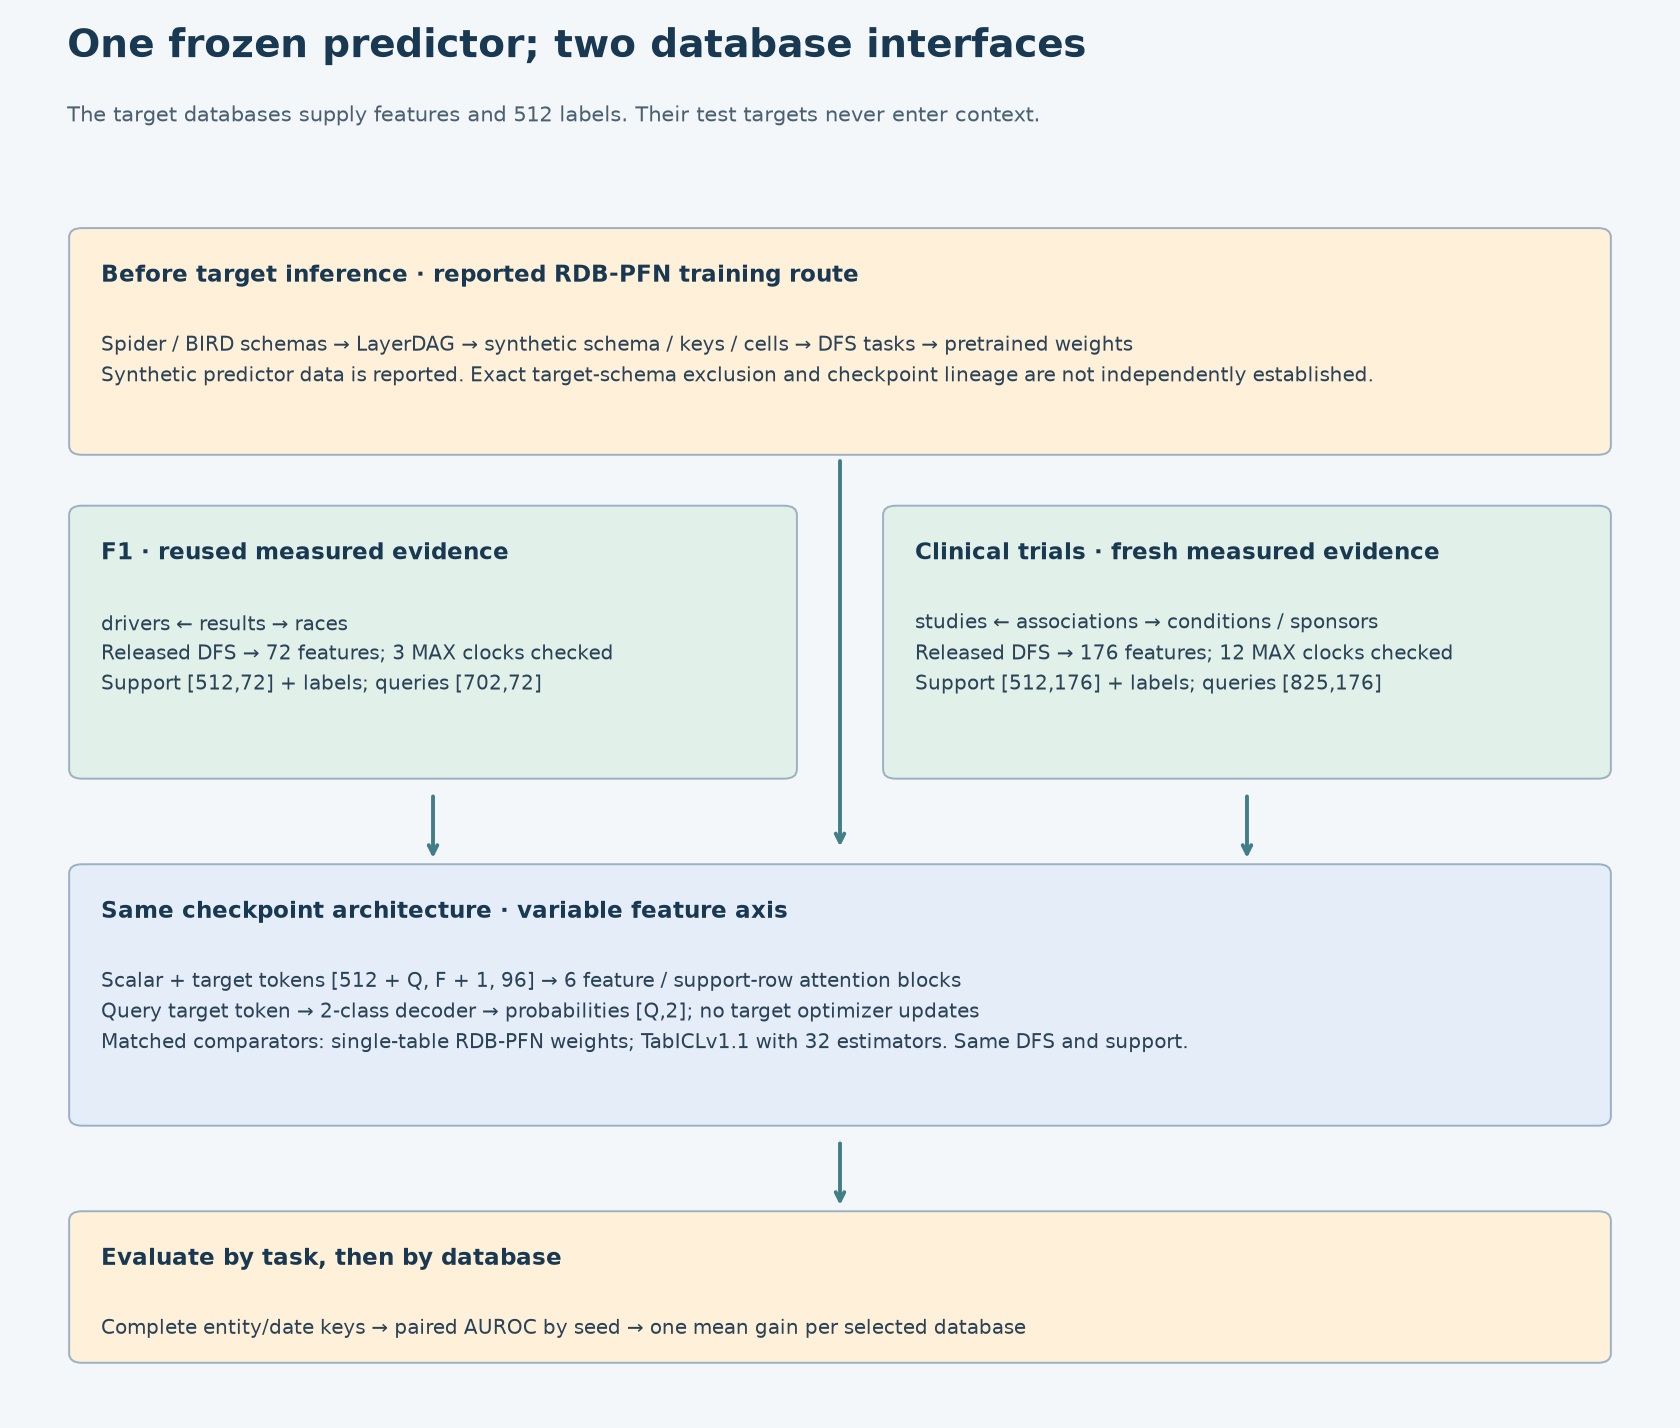<figcaption>Same frozen RDB-PFN checkpoint across two DFS feature widths. F1 evidence is reused, trial evidence is fresh; schema-generator provenance is a separate question.</figcaption></figure>

The same RDB-PFN checkpoint handles both constructed feature widths. Its alternating feature and support-row attention operates on a task matrix; it does not receive raw PK/FK edges at inference. DFS supplies those relationships through joins and summaries. TabICL receives **the same matrix**, so the comparison tests the released predictors under matched preparation. [Lesson 166](https://avistian.github.io/relational/lessons/0166-rdb-pfn-synthetic-relational-priors.html) contains the complete visible checkpoint-compatible implementation.

**Schema compatibility is not semantic invariance.** Renaming a table is harmless only if the preparation still resolves the same relationships and values. Changing a join, dropping a child table or shuffling category meanings changes the actual information supplied. A model accepting 176 columns does not prove it understands every new schema.

## 3 · Separate adaptation from exclusion

[Griffin](https://arxiv.org/html/2505.05568v1) studies transferring pretrained graph representations with supervised target adaptation. [RDB-PFN](https://arxiv.org/html/2603.03805v5) uses labeled target context with frozen weights. Both can be evaluated on a database excluded from predictor training, but they spend the target labels differently. A fair comparison must declare the label budget, optimizer updates, feature access, validation selection and test population.

<figure class="route-figure" tabindex="0">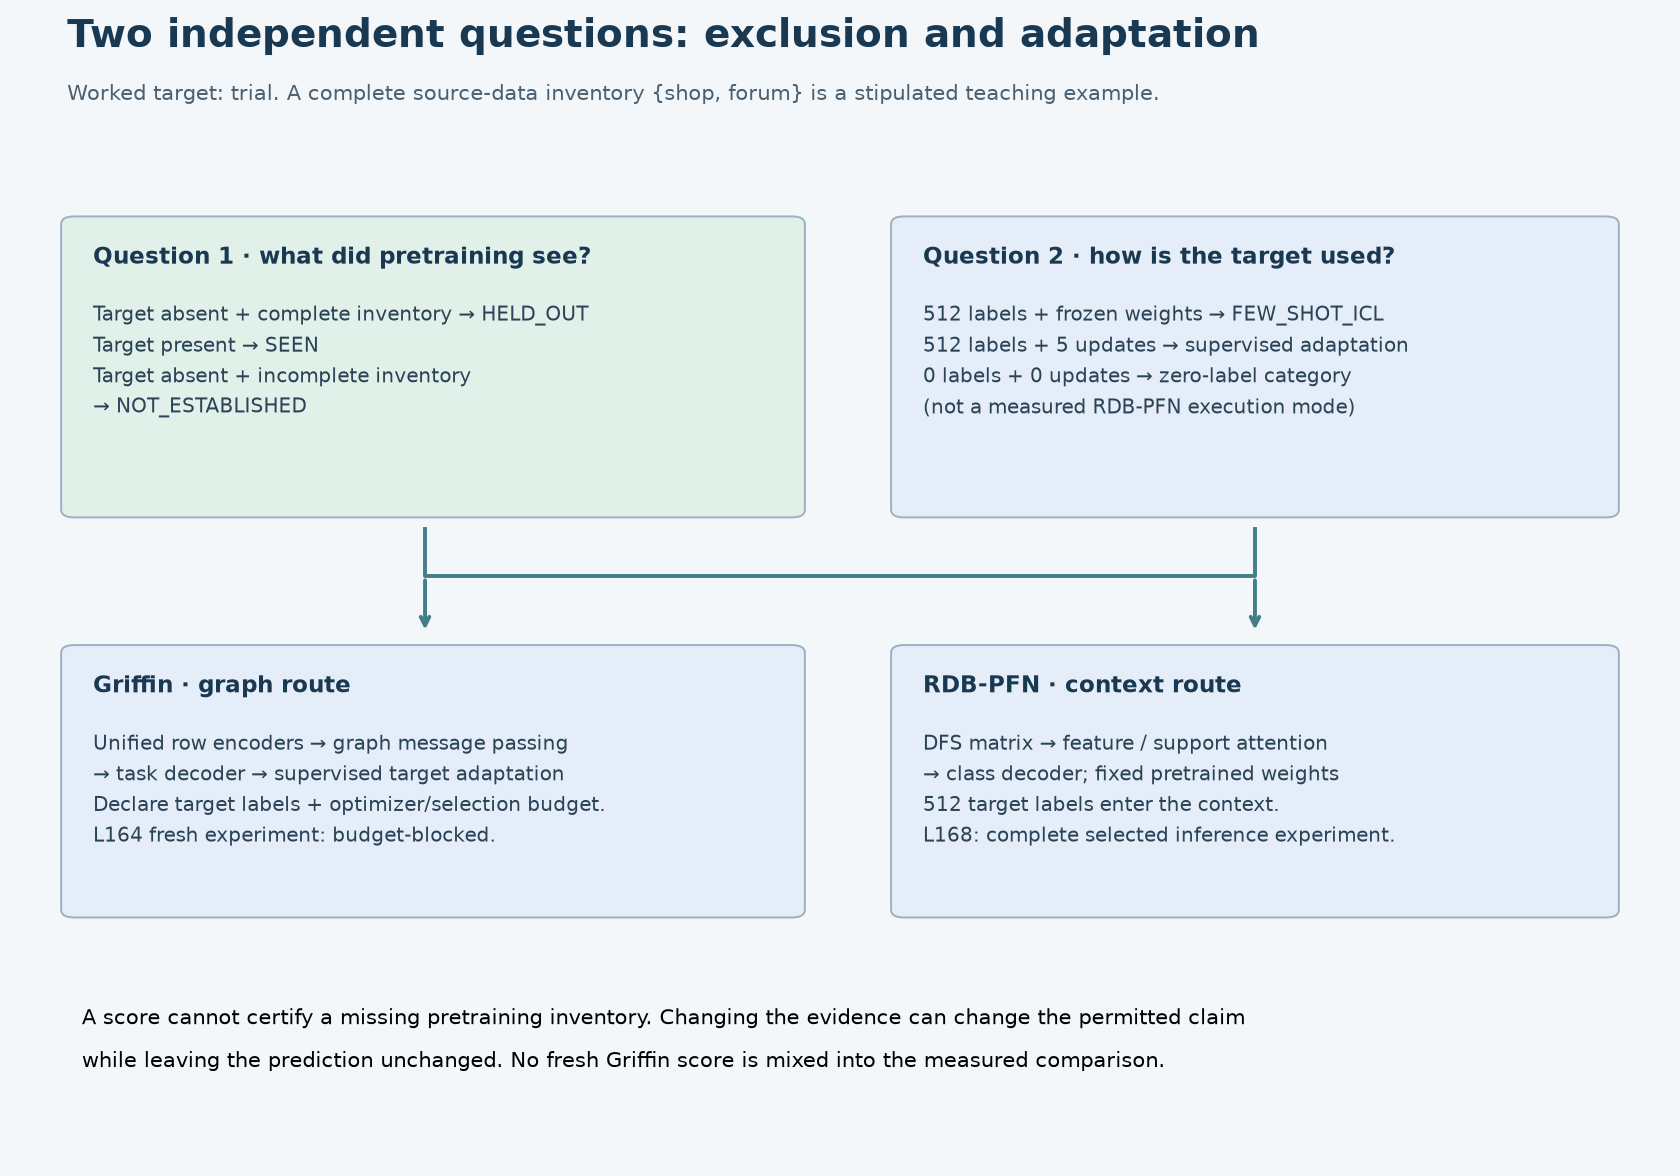<figcaption>Pretraining exclusion and target adaptation are independent axes. Griffin uses graph computation and supervised adaptation; RDB-PFN uses DFS and labeled context.</figcaption></figure>

**Worked trace:** suppose the complete pretraining database list is `{shop, forum}`, and the target is `trial`. With 512 trial labels and zero updates, the target is held out of pretraining under that stipulated list, and adaptation is **few-shot ICL**. Five supervised updates change the adaptation classification. If the list is incomplete, holdout becomes **NOT_ESTABLISHED**, even if predictions stay numerically identical. If `trial` appears in the list, it is **SEEN**.

Baseline: incomplete lineage + 512 labels + frozen weights → NOT_ESTABLISHED / FEW_SHOT_ICL. With a complete target-excluding inventory → HELD_OUT / FEW_SHOT_ICL. Test all interventions with the code below.

This exercise classifies a protocol, not model performance. Its hypothetical zero-label setting is not a runnable zero-label RDB-PFN mode. The measured experiment always uses 512 labels. The invalid combination of supervised updates and zero labels is rejected by the notebook contract.

Implement the exposure/adaptation contract in the TODO cells below.

Griffin’s [Lesson 164 reproduction](https://avistian.github.io/relational/labs/l164-reproduction.md) remains **INCOMPLETE_BUDGET_GATE**. We explain its adaptation procedure and cite its paper; we do not put an unrun Griffin score in the freshly measured results table.

## 4 · Complete selected reproduction: a second database

Our new experiment is **RDB-PFN v5 Table 9, rel-trial / study-outcome, context size 512**. All ten seeds, three fixed model arms and the entire 825-row test split are evaluated. No lighter TabICL ensemble, smaller test subset or post-test checkpoint choice is substituted. The complete F1 experiment is authenticated and rescored as **reused** evidence. [Published targets and protocol](https://arxiv.org/html/2603.03805v5#A6.T9).

| Contract | Fixed choice |
|---|---|
| Models | RDBPFN `00528`; single-table checkpoint `00360`; TabICLv1.1 with 32 estimators |
| New data | Released trial DFS depth-2 task; 11,994 train / 960 validation / 825 test |
| Support | 512 train rows; ten deterministic draws; identical identities across arms |
| Preprocessing | Original sorted numeric/category features; support-only median fill; original model normalization |
| Selection | Checkpoints and settings frozen before new test scores; no validation tuning |
| Evaluation | Exact `(nct_id, timestamp)` keys; all 30 runs; AUROC mean and sample SD |
| Stop rule | $10 aggregate cap; pilot timing gate; record incomplete work if the full protocol cannot fit |

**Read the label before interpreting a probability.** All 13,779 trial labels equal **one minus** the pinned RelBench task labels after exact study/date alignment. The original task marks a qualifying primary outcome positive when its minimum eligible p-value is at most .05 within the next 365 days. The released RDB-PFN labels reverse that orientation. Reproduce the released labels for its score; complement both labels and probabilities when discussing the original outcome direction. AUROC is unchanged when both are complemented. The released class-1 probability needs that complement before it expresses the original primary-outcome direction. [Pinned task source](https://avistian.github.io/relational/labs/sources/l139/relbench__tasks__trial.py).

Twelve exposed maximum-timestamp columns pass their owner-cutoff checks, and every training label’s 365-day horizon ends before the earliest test query. This does **not** certify every DFS feature or historical arrival time. We did not regenerate DFS from the full raw database. RelBench’s retrospective cohort and inferred dates retain the limitations explained in [Lesson 139](https://avistian.github.io/relational/lessons/0139-healthcare-trial.html).

| Database / evidence | Model | Paper AUROC | Measured mean ± sample SD |
|---|---|---:|---:|
| rel-f1 / REUSED_L166 | RDBPFN | 0.7219 | 0.721938 ± 0.019983 |
| rel-f1 / REUSED_L166 | RDBPFN_single | 0.6640 | 0.663990 ± 0.034177 |
| rel-f1 / REUSED_L166 | TabICLv1.1 | 0.7176 | 0.717568 ± 0.009770 |
| rel-trial / FRESH_L168 | RDBPFN | 0.5986 | 0.598556 ± 0.021570 |
| rel-trial / FRESH_L168 | RDBPFN_single | 0.5961 | 0.596101 ± 0.021897 |
| rel-trial / FRESH_L168 | TabICLv1.1 | 0.5926 | 0.592820 ± 0.030357 |

<figure class="route-figure" tabindex="0">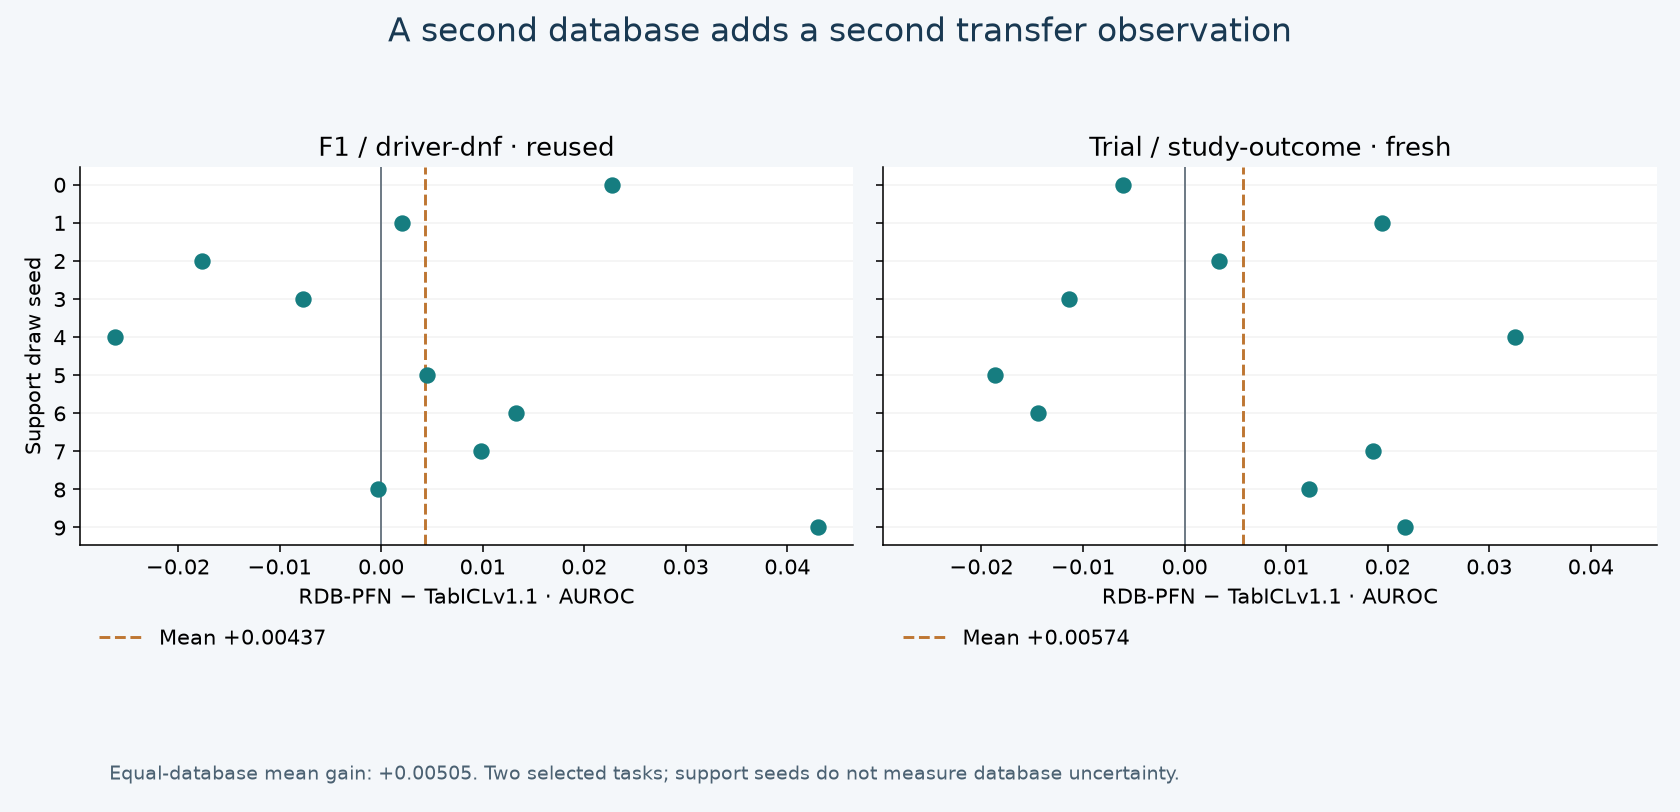<figcaption>All ten paired RDB-PFN minus TabICL AUROC differences per database. The horizontal scale is shared; seeds measure support variation, not the distribution of new databases.</figcaption></figure>

RDB-PFN minus TabICL averages **+0.00437 AUROC on F1** and **+0.00574 on trial**, positive in 6/10 and 6/10 support draws respectively. The equal-database mean gain is **+0.00505**. All three fresh trial means are within the predeclared .02 descriptive distance from the published values; this is not a statistical equivalence test or proof of historical data identity.

The new evidence is 30 complete trial evaluations and **24,750 fresh probabilities**. The comparison also independently rescores 21,060 reused F1 probabilities. Both selected task means favor RDB-PFN over TabICL, but seed-level reversals and only two databases prevent a broad-superiority claim. The small trial gain over its single-table ablation also cautions against attributing every gain to the relational prior.

## 5 · Aggregate at the unit of the claim

For database d and support seed s, compute `delta[d,s] = AUROC(RDBPFN) − AUROC(TabICL)`. Pair by **database and seed**, after matching all query and support identities. Average the ten deltas within each database. Then give each selected database one weight in the macro mean.

**Hand-worked counterexample:** a small database gains +0.10 and a large one loses −0.20. Their equal-database macro gain is `(0.10 − 0.20)/2 = −0.05`, regardless of row counts. Pooling predictions from different tasks changes the estimand: score scales and target meanings differ. Counting ten support draws as ten independent databases also overstates the evidence. The plotted sample SD describes support-selection variation on a fixed test population; it is not a confidence interval over new databases.

**Make the weighting visible.** Give the invented small database 100 test rows and the large one 900. Keep their gains fixed; this is a comparison of estimands, not a re-run of either model:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:3px"><thead><tr><th>Weighting</th><th>Calculation</th><th>Mean gain</th></tr></thead><tbody><tr><td>Equal databases</td><td>(+0.10 − 0.20) / 2</td><td>−0.05</td></tr><tr><td>By row count</td><td>0.1 × 0.10 + 0.9 × (−0.20)</td><td>−0.17</td></tr></tbody></table>

The second row is a row-weighted average of two AUROC differences; it is **not** an AUROC computed from pooled predictions. Both are defined quantities, but only the first answers this lesson's equal-database question. **Transfer check:** add a third database with gain +0.20. The macro becomes `(0.10 − 0.20 + 0.20)/3 ≈ +0.0333`, regardless of its test-row count. More support draws on the original two databases would still leave two databases.

An **estimand** is the quantity the comparison is meant to measure. Here it is the mean task-level gain across the two selected databases. **Macro** means each database contributes equally. SD means standard deviation, the spread of the ten support-draw results; changing those draws does not create additional databases.

The notebook makes you implement three load-bearing functions: classify exposure/adaptation, assemble complete paired gains, and calculate the equal-database macro. These functions feed the actual saved-evidence audit and final table. Checks reject a missing seed, duplicate run, mismatched test count and mixed metric; the raw audit separately rejects wrong keys, supports, labels and hashes.

## 6 · Exit: write the claim you can defend

Fill the [cross-database table and defense](https://avistian.github.io/relational/labs/l168-transfer-template.md): exposure evidence, representation, label budget, updates, metric, measured/reused status and unresolved limits. Write 250–400 words answering: **What did the trial run add beyond F1? What would a third database add? What evidence would establish exact schema novelty?**

Pass rubric: 0–2 each for exposure, adaptation, pairing, aggregation and evidence limits; target ≥8/10, no zero, and teacher review. Running the solution is author verification, not learner mastery: **PENDING_WRITTEN_DEFENSE**.

Write the cross-database defense; distinguish verified inference, reported pretraining and unknown schema novelty.

**Primary reading:** [RDB-PFN §6.1, Appendix A.3, C.1.1 and Table 9](https://arxiv.org/html/2603.03805v5). Read [Griffin’s transfer experiments](https://arxiv.org/html/2505.05568v1) to locate its target adaptation budget. Ask me follow-up questions about any step—especially the difference between verified inference, reported training provenance and schema novelty.

Next: Lesson 169 asks what scale and diversity evidence we would need before calling these observations a scaling law.


In [ ]:
# @colab-bootstrap
import os
os.environ.update(OMP_NUM_THREADS="1",OPENBLAS_NUM_THREADS="1",MKL_NUM_THREADS="1")
import base64,hashlib,io,json,zipfile
from pathlib import Path
import numpy as np
P=Path("l168-portable");P.mkdir(exist_ok=True)

## PROVIDED · Authenticate the original evidence
This packet contains all 60 raw prediction arrays (30 fresh trial +30 reused F1), original receipts, full prepared matrices, and pinned original model source. Computation remains visible below; the payload is data and source files, not an opaque executable helper.

In [ ]:
encoded='...'
raw=base64.b64decode(encoded)
assert hashlib.sha256(raw).hexdigest()=='613f8af674eef3800da69c9b7cce91068158f98f207021c017b10fcfd81f5440'
with zipfile.ZipFile(io.BytesIO(raw)) as archive:
    for name in archive.namelist():
        assert not Path(name).is_absolute() and ".." not in Path(name).parts
    archive.extractall(P)
pins={'experiments': [{'database': 'rel-f1', 'task': 'driver-dnf', 'folder': 'evidence/l166', 'train_rows': 11411, 'test_rows': 702, 'features': 72, 'seed_key': 'rel-f1-dfs-2:driver-dnf:{seed}', 'phases': ['pilot-2', 'full-1'], 'evidence': 'REUSED_L166', 'targets': {'RDBPFN': 0.7219, 'RDBPFN_single': 0.664, 'TabICLv1.1': 0.7176}}, {'database': 'rel-trial', 'task': 'study-outcome', 'folder': 'evidence/l168', 'train_rows': 11994, 'test_rows': 825, 'features': 176, 'seed_key': 'rel-trial-dfs-2:study-outcome:{seed}', 'phases': ['pilot-1', 'full-1'], 'evidence': 'FRESH_L168', 'targets': {'RDBPFN': 0.5986, 'RDBPFN_single': 0.5961, 'TabICLv1.1': 0.5926}}], 'files': {'evidence/l166/full-1/RDBPFN-1.json': '77e8144ebf3cf3c0deb2f4567d1169e34487a4da3f8839134687ef48f9988fca', 'evidence/l166/full-1/RDBPFN-1.npz': 'b234f020b1076ea01e1f38dc048e7f3be8aea6dcba21da845d8ca0fca72a7fae', 'evidence/l166/full-1/RDBPFN-2.json': '2f822f19b5416d29c4dc671615e4f0e2533f3a961de3191c392f0465be3a8b0d', 'evidence/l166/full-1/RDBPFN-2.npz': '874bf69e6c96d57e8a93936cd2d2e46c778ded54ae93edd4b8a62516ae62398f', 'evidence/l166/full-1/RDBPFN-3.json': '0ceed06dc7e6f3a85eac3cb1b7dc6bc41a8a45da7a1f6c9b60ce6fabd8aa9a04', 'evidence/l166/full-1/RDBPFN-3.npz': '3f01dd8ca7ffeb66f98aea347ef2592f23e1ba70df6f832a97825ae06b113a4b', 'evidence/l166/full-1/RDBPFN-4.json': 'cfe948de7c172ddcfad41c54a13a84e5ab97934261cb44e86014011005f58e43', 'evidence/l166/full-1/RDBPFN-4.npz': 'ae2ddcbdf66ebac5a196349f54a1f4d34c9df98e8660c97e70829606ab4a8dc9', 'evidence/l166/full-1/RDBPFN-5.json': '19c411b2922a1c5bfb592bcdd9f07deae8e2373599ce813f1f724582dedada75', 'evidence/l166/full-1/RDBPFN-5.npz': '02803816d249ca1f275dfed37870f90992aafcd1d30bc53d3a62f64a6456f93f', 'evidence/l166/full-1/RDBPFN-6.json': '263f55a923e9525f450df5b9748a89085abdc0d9d4b0f90a0e0ac7d07bde061f', 'evidence/l166/full-1/RDBPFN-6.npz': 'aae3b3c774b9cc1364770f2037eba3cbf4a7ed7cd6e543432175e92d8ed3bbd2', 'evidence/l166/full-1/RDBPFN-7.json': '97839b67f58eec186bb86b0a3a22b469d3f799e4f1d9e823d950dac35d044799', 'evidence/l166/full-1/RDBPFN-7.npz': '0e74602505fee5446e8da5d2532dc568f1616fbc6af1608e1c70706e36fdc839', 'evidence/l166/full-1/RDBPFN-8.json': 'bc8b92f11b5ff4e035c77a04b04b8b3e54949e2e6aad170cce5808076e15bed5', 'evidence/l166/full-1/RDBPFN-8.npz': 'd9c3d8b5c2f847d040e7302b607a5e3cec0da79c0e1e4634b5ee75b73592eee6', 'evidence/l166/full-1/RDBPFN-9.json': '364aa5e7b224829c0af24f90c25dc6feff1df6cf79f858bb5dcf1eed1b73ccbe', 'evidence/l166/full-1/RDBPFN-9.npz': 'df98ef5462c41dbdc064760b35caf8ca3819dc9fc6836880410310e4d62aedb2', 'evidence/l166/full-1/RDBPFN_single-1.json': '322a27203bc43efcfde26a10bf4a773e1ff7f7844cc222364cfd8c27ce43c8bd', 'evidence/l166/full-1/RDBPFN_single-1.npz': 'a5d87cde2d885b55a92e1bd248fb562e55a5e1acd9e8ce2c08c86500bf693b50', 'evidence/l166/full-1/RDBPFN_single-2.json': 'c36358f70d997462066289fa21235a8b716e2e1e7649480cd710b4b22d504917', 'evidence/l166/full-1/RDBPFN_single-2.npz': '1ad0c3c73462f95d4bfb12e6bccdc8c1ed1fe8f219411e84926e0c13d39bc8a7', 'evidence/l166/full-1/RDBPFN_single-3.json': '82941f1105f7dc37f4cb17dfc9c17d97fbe71653b52e62203137af03e992de21', 'evidence/l166/full-1/RDBPFN_single-3.npz': '72f566d2e5270b35fae3ab9ccc8c60d7f95f06530fa164dc74f77159e5cbec78', 'evidence/l166/full-1/RDBPFN_single-4.json': 'a380c3ae08158c56a2770295d688b5b1d389c352e8e84bd61878ee249d0dc922', 'evidence/l166/full-1/RDBPFN_single-4.npz': 'ee3f8128682b2e9ff168fd14ad11cd629274463f1d30ca65e9a0d5c87b89e69e', 'evidence/l166/full-1/RDBPFN_single-5.json': '8f9ab68937f54c6565ba62b7879a56ecd49b166957e1db8595f095fbbc1929d1', 'evidence/l166/full-1/RDBPFN_single-5.npz': 'bf966a1143912259be2aff2f8d1e1460992039363c347960234f204c58e14075', 'evidence/l166/full-1/RDBPFN_single-6.json': 'e28a4aabd0dc4883da233daa98041cb86f186fa1a8b4b2a5bed37a86fde1a3f9', 'evidence/l166/full-1/RDBPFN_single-6.npz': 'bbd130e58fbd44eec1783a78019adccb15bd6eace254af5f32ee0aaae8ecf989', 'evidence/l166/full-1/RDBPFN_single-7.json': '623d0223fd7e156972538217088e1a9d2acf961ccfd5fbdb1c09971f487f6c83', 'evidence/l166/full-1/RDBPFN_single-7.npz': '02a158e9d726f4553f9e8c76d17810ccf1d2e8c5c4e9de964a0ca7b64b9e2389', 'evidence/l166/full-1/RDBPFN_single-8.json': '5a4e2479c7c2794110c28c2f0668e35309b0f797379a4529b60a804ed1bd6180', 'evidence/l166/full-1/RDBPFN_single-8.npz': '85bb14ba7154e7aa90e794f9a49e478b1d35e6e064031964d3715e215b72b18b', 'evidence/l166/full-1/RDBPFN_single-9.json': '81d617162a00b524a4ccd59a50c021d5f58742689ea6beedc198644e22dad242', 'evidence/l166/full-1/RDBPFN_single-9.npz': '693cf63d27383e8e603de6ae4f30f993cf4e5bf19afb46972d3c169c03bc6659', 'evidence/l166/full-1/TabICLv1.1-1.json': 'f1fb6da5940958367235e93318d985418bbf41364a546965353f0b0674f25a93', 'evidence/l166/full-1/TabICLv1.1-1.npz': 'd25c341b6145eed5380866e54ae6f4753d798f9d461125dce1ad41ef1a6efa14', 'evidence/l166/full-1/TabICLv1.1-2.json': '61ee12f173c16320d433ab118830b9486d333e205ee88b19f63225198d35d708', 'evidence/l166/full-1/TabICLv1.1-2.npz': '8b9f2f0b0f9dcacea0ae95923e56fd961e3ffbbc361c4b6ed8535a954b971bfe', 'evidence/l166/full-1/TabICLv1.1-3.json': '5cacbb86f23358664bba40c19c2b75f05cf3498883f65b50f3ff0b8d61772183', 'evidence/l166/full-1/TabICLv1.1-3.npz': '85c55bb62822daa0e305b552f3a0a6ce9149feec8a80c5f8762a92ac6a0b1f44', 'evidence/l166/full-1/TabICLv1.1-4.json': '3c05ef05465b7e041442e6160b133de802034b653251d90293b04b0cdd1638a8', 'evidence/l166/full-1/TabICLv1.1-4.npz': '8d8f2e3eaa791be21f31f939e2011bfe016269e35b8a3371473dcda9454e7022', 'evidence/l166/full-1/TabICLv1.1-5.json': '18672fc4be20978eebc5e53d486c4e2f58dc935ea898e7b6dd721fad229ae339', 'evidence/l166/full-1/TabICLv1.1-5.npz': '3000d3e27cd2288ad33b9161f8bb313d6ce34a5b9bd21f5f3050e6b2d1937083', 'evidence/l166/full-1/TabICLv1.1-6.json': '6956ecc86e884e5f7b9efd7f72eb6d58d08e1aa4e27d26b3c2facce5cc9be9c8', 'evidence/l166/full-1/TabICLv1.1-6.npz': '91eb8ebecd2c4b71cb6bf40c1f001f44e403d8005b4e612675b9cc59309de69f', 'evidence/l166/full-1/TabICLv1.1-7.json': 'cc08adf22ad2c8beb92e8a9f9a95e1a35faa89bc8a3951c792071b5c0826068a', 'evidence/l166/full-1/TabICLv1.1-7.npz': '353f764d50857e8386ac204aca05d34d044f07832f9ff95e5cbe7784a3be0ead', 'evidence/l166/full-1/TabICLv1.1-8.json': 'cdf1e64f6d0892f228b9c30cbac6e5f7df483ad1f63b2ad651f41f1d72f039d2', 'evidence/l166/full-1/TabICLv1.1-8.npz': 'e2269ccfca7cd52c45334786489856103e544b9b244363452ee64b26f4cb7226', 'evidence/l166/full-1/TabICLv1.1-9.json': 'abb2902f28e82555a62c2f35e7ddd1a1c18c07e3a24af4af1214bfbbfb7cad8a', 'evidence/l166/full-1/TabICLv1.1-9.npz': '1025f3d8eff81dea26b142a78c33af9ff95a0b02d8d477804ffb1f52233218e9', 'evidence/l166/full-1/cost.json': 'cd60fc826070e00fbe74d86c8dea944503273cc11709d1be8865eff68ba5aab8', 'evidence/l166/full-1/receipt.json': 'c80106b3673acb3e6f690292f13eb98d6a606119ac7392a6bfc9c8023f5cc35b', 'evidence/l166/input-manifest.json': '76d0c10a4f083136dfac5254e57788770381887443b722e47ff9484998206b1f', 'evidence/l166/pilot-2/RDBPFN-0.json': '2225dbba68eecad5345e788903337d7075f4b12bf6316fefc9180c601fa4a3c6', 'evidence/l166/pilot-2/RDBPFN-0.npz': 'efaaa6982c5c5782e22d35ec4cc9fc82adb33703d8d6ac1206b987b81e4ed9e6', 'evidence/l166/pilot-2/RDBPFN_single-0.json': 'cc08f124378ea22b72599da35f03c2ea45023fee5459873ac6926011f49c9bd5', 'evidence/l166/pilot-2/RDBPFN_single-0.npz': 'ec98be9f74006395e5f5cf5a54087dc54cc661eb8f956200781f4c2fa470bfe8', 'evidence/l166/pilot-2/TabICLv1.1-0.json': '034d0cfba214ee823d79ba5c79ee971c68e6170fd41c3997067361b4a6dfda3e', 'evidence/l166/pilot-2/TabICLv1.1-0.npz': 'eff980b9aef9eff48c388721fd2da896f2847390d65605e028b24b334099e681', 'evidence/l166/pilot-2/cost.json': '2afd19ca19bca94373af66379f1bec729aa10ce31f5e50b6282afb504c73faf9', 'evidence/l166/pilot-2/receipt.json': '52efe0d8c66f00859a1c99e65e1806f4d334d23e9d5bf3e31ce731a1bcc4de1f', 'evidence/l166/prepared.npz': '9f4a0e9245420127c6391196bdc1a33dba4bbb88bdf3e42161912e3763a20bbe', 'evidence/l168/full-1/RDBPFN-1.json': '362e1d0903760d9fe259f71998f68718302100c6d091aae2c10283508bd8febe', 'evidence/l168/full-1/RDBPFN-1.npz': 'f181c74d2dcd8eafc93797b8d1c2f2cb9a7db82e0fe4fd97b83ca7ad050a7aa6', 'evidence/l168/full-1/RDBPFN-2.json': 'b86ab173a63504b9dedefce9cbb414132e6a18c9f574de0e3e588b77291c584d', 'evidence/l168/full-1/RDBPFN-2.npz': '74e756e58dab41bd6bc9a71b62650770bc0d322e31b1f878b55334618ce96494', 'evidence/l168/full-1/RDBPFN-3.json': 'df30ca1f88962e2a03dbff933e09258aa7f67e99ffa5c4e07e9fdb6ff2e31d31', 'evidence/l168/full-1/RDBPFN-3.npz': '9c07c0d3ee95d6b8d613e5589d02c4437ffac25c1cdb2091680691c212952bd6', 'evidence/l168/full-1/RDBPFN-4.json': '93a606278e293f8a74dc919002c6d8d641b0211970a480bdcf8228067c8d211d', 'evidence/l168/full-1/RDBPFN-4.npz': 'e57a0f205bcc7799465eba329dbb59894af4a05d72a034e67c0fcb425e2a689f', 'evidence/l168/full-1/RDBPFN-5.json': 'ded68fb973554f52d8cdea9d497870b4b04f7606f5dc5b9fcee9568c727b693b', 'evidence/l168/full-1/RDBPFN-5.npz': 'ae433f4a8943c0bdf9902bcecd08ceb33fed895b511b81ae68a03a81509a2b2c', 'evidence/l168/full-1/RDBPFN-6.json': '9692122cc660c1aed91881af1f47de26d97dcd60d372a51983df099bf870bdb7', 'evidence/l168/full-1/RDBPFN-6.npz': '4b3f32bfad7397d8f694f7a4a1de560945120d121b1675938cbc89010abff3ca', 'evidence/l168/full-1/RDBPFN-7.json': '831b0d01d463fffff50356e6eae4ee319ca25a3d1b9d8f5e0562218f0093e8ea', 'evidence/l168/full-1/RDBPFN-7.npz': '42b7f3dbf50002c13a29d59b9be1651c9a23c4ae2c3d2ddff162004ec4529fac', 'evidence/l168/full-1/RDBPFN-8.json': '3230c621a06b0746d80158654c6adee845ad5266ed9e85c8d0cc675df1123da5', 'evidence/l168/full-1/RDBPFN-8.npz': '159b1fb90137f1fc0c9c0cc35fcac25bafabbea662ee2145859bf5f74c31c794', 'evidence/l168/full-1/RDBPFN-9.json': 'a848a2ba8f2ccf1819c86ea7f6d11f28eaeff46f7e1ae55e07d93d4787226a6c', 'evidence/l168/full-1/RDBPFN-9.npz': '9b2919ef909d321a94b94500ac486d6f1381fc92d8fef9a89e2e50096d139f6e', 'evidence/l168/full-1/RDBPFN_single-1.json': '5c67b707691aacabe7f0e0873ea204ce7c62dd86923d3d3aea6247ba1681bd74', 'evidence/l168/full-1/RDBPFN_single-1.npz': '7ce7b804f1154e38083b65214ba116abd4304f5ab85ae4aade1fceed49da20d1', 'evidence/l168/full-1/RDBPFN_single-2.json': '3fa910dce655f6bcececbcc94f258a6f9587f1003e3d8a8d9c3d53f99fcaa6f6', 'evidence/l168/full-1/RDBPFN_single-2.npz': '98297d7a3304bd93f65579123025f66c750041e2f08a9b3f363b74ecd8dcaa7d', 'evidence/l168/full-1/RDBPFN_single-3.json': 'e8a8c126f38b103c3c9934f934c41d936e934c77560a67b342fd9887e13878cb', 'evidence/l168/full-1/RDBPFN_single-3.npz': 'ce6477e3f0b756e175e49eee3251e6bfd0777038cacfab934873008410de1e0a', 'evidence/l168/full-1/RDBPFN_single-4.json': '3cd5212f650179f9bc3d6d9b2a0309b3d6d5ba537940524d750be3e388e4cc78', 'evidence/l168/full-1/RDBPFN_single-4.npz': '57e649c584975fb5b9628696ffcef1529ef1d276821822e48187e34a47ef26e7', 'evidence/l168/full-1/RDBPFN_single-5.json': '5d937875476db88798c1ab327af75a7dfdc5c1a1cc2cdb4ad9ba9bb95b9ba389', 'evidence/l168/full-1/RDBPFN_single-5.npz': 'fc815529281eae307c88c8e2978f8ac21f98e4a959341855cb374cfbbc586f91', 'evidence/l168/full-1/RDBPFN_single-6.json': '3050ef98bf17b1b0ead0313f9eb2fe6026d312129edbe29bdb87953e47051b87', 'evidence/l168/full-1/RDBPFN_single-6.npz': 'dec4f11087b95b120da674003a416588ed4b23d0b86dea26cf3122514b24c844', 'evidence/l168/full-1/RDBPFN_single-7.json': 'fcbbb5ece8061d2f125490cdebd3f2833314797e3d1ebb39752aa1d61aac64dc', 'evidence/l168/full-1/RDBPFN_single-7.npz': '54fe6827ffd0e44878b211f6af60d252a21ec86d5cb03d12f48b5f29d18d6080', 'evidence/l168/full-1/RDBPFN_single-8.json': '6fd12e31939a8051a28c0495322f1aa4aa96bb23c647c04cfc620df95a50e466', 'evidence/l168/full-1/RDBPFN_single-8.npz': '084f28716548af6884f274e3964dfe8c525a6b2ea05335717c1ba6a5522ce553', 'evidence/l168/full-1/RDBPFN_single-9.json': 'e90fd48f9ca4208175da3efcbe1661a667d4bbfa9c012bd70f5e4cdd3dd217e4', 'evidence/l168/full-1/RDBPFN_single-9.npz': 'c2590b301c13f9c6dc8ffb66f3a8e13cf934487ac6be5cf748e395a9d3344b7a', 'evidence/l168/full-1/TabICLv1.1-1.json': '7dd4d6e2f81b348b03a9057f60625531ea40ae40fcb794243d062a19c10484b8', 'evidence/l168/full-1/TabICLv1.1-1.npz': 'c251e086886ab2de9d739ec1fa532d10d371a0855d57b356ca98a8f663442be7', 'evidence/l168/full-1/TabICLv1.1-2.json': 'f52aae7af3aeebd5d7071400da0ecb1b328fb41a05fefe03549b5b473287a444', 'evidence/l168/full-1/TabICLv1.1-2.npz': '0805e97a8fe278fa2871c85297db3bac9bbe5e44be595ab32ca05e801ebf14e2', 'evidence/l168/full-1/TabICLv1.1-3.json': '511329b1210e5b6352bbc1dfa5ba15f9271da86d9dbe4809117610aad7d4ff8a', 'evidence/l168/full-1/TabICLv1.1-3.npz': '27b5149877f7dbc1ffc75e34cde0fecf03719cfebaadb8159065d5c4c6346b30', 'evidence/l168/full-1/TabICLv1.1-4.json': 'd0feaae540c6f538ab813d2ec04caf0388241426d0894700f654041de2b72a74', 'evidence/l168/full-1/TabICLv1.1-4.npz': '510a3538ce0e502b8adade3650991053f630316682a44f9fd60644eabd6e0122', 'evidence/l168/full-1/TabICLv1.1-5.json': '2c6a1f794f82ea9e06034a3a99c8c6e71acdd4aa297f104c7b959635a9564bf2', 'evidence/l168/full-1/TabICLv1.1-5.npz': '7f40de3553fa96628366d3c562c6986ced997ee5f006a2b102c1e56e12f3a2a9', 'evidence/l168/full-1/TabICLv1.1-6.json': 'd7a008a8fcddc22cc4b9fc77e616c2692b0c81e0fd0d887412cf1786c45e58fd', 'evidence/l168/full-1/TabICLv1.1-6.npz': '2e22b6a28594ecae9fedca4b7cdeabfa07f489bf748b0b3d6e5f5612f2f6277c', 'evidence/l168/full-1/TabICLv1.1-7.json': '2cbec2b056cfa79a560cfc20dc164c2c8e1abe536b4745fa282fe19d80b28f4a', 'evidence/l168/full-1/TabICLv1.1-7.npz': '1ed39ee1b3168c3f747c6ce92e7921d6fadb6a88ce0f877db10197e0581d178c', 'evidence/l168/full-1/TabICLv1.1-8.json': 'c5a7986fd02278089dfb0a2c29cdeb915512ffd35e088be34a61a46dd230941c', 'evidence/l168/full-1/TabICLv1.1-8.npz': 'b0079ce6208769db584a1e9c9842a743a0f37d4efad41fd760e1bf1b3f2aaa89', 'evidence/l168/full-1/TabICLv1.1-9.json': '1eb6a82302d3af530fcaa701bcfaa1d790afd7b0f568500a88f99bd200fb47db', 'evidence/l168/full-1/TabICLv1.1-9.npz': '20013aa22c32eea670190c12703862c011fbc92e4e5cf3bec29a6ffc9b9c11e4', 'evidence/l168/full-1/cost.json': '76911645a9887afe95c3557f1b0ac7e57711002eeca4b9afdc6c240c47766fa6', 'evidence/l168/full-1/receipt.json': '5432c1d5efb2310d014562d5edf35a1c6101c16b8313ba6a244b1f447e76775e', 'evidence/l168/input-manifest.json': '5972ad54331cf792aa2e48ed18e41abdd030ecc013beda2549f9223216f6e8e3', 'evidence/l168/pilot-1/RDBPFN-0.json': '6e72378dd3d1cfc5f856cf9b148571792d3e5bfa1ff387cf6497a21e64b937b8', 'evidence/l168/pilot-1/RDBPFN-0.npz': '1a968155676e7459245f31ce3ae2d64f492019c7f67c3ff97178278dc5eaf086', 'evidence/l168/pilot-1/RDBPFN_single-0.json': 'a61fec3a130872c97e40d9b344a5104d8ae0aecd6c15acea2eba7ac1f2d246ad', 'evidence/l168/pilot-1/RDBPFN_single-0.npz': 'a91c36544ae9a530ba094bd3c53c606222ac5e31e4dee1583e910d7426568d9b', 'evidence/l168/pilot-1/TabICLv1.1-0.json': 'ba71530ce2e8ad333f0e87a1522987487410c647c78a41dc8d61479b9b0c5121', 'evidence/l168/pilot-1/TabICLv1.1-0.npz': '23c9305c4c2ccb8129acf59a6b4a69fa7f887284d7ffe187aca95f59bcd0d8b9', 'evidence/l168/pilot-1/cost.json': '0f49d34730da4912b9131d215b54758e2826531d9a244cac705d63efd72501df', 'evidence/l168/pilot-1/receipt.json': '03a8564151eb44aabae1f6016a32bc5fd1260c0280342034d9d66c394bfc1060', 'evidence/l168/prepared.npz': 'e4476ae0c6ff7ec8ba6ef9ef282c0cd338daf6b69ee959782b6f26bc153a9bb5', 'sources/l166/source-ledger.json': '45c5caaa403ed1d5aabd51a743563a54cf779a8bf38e093f595f1b25047da8fd', 'sources/l166/upstream/model_pretrain/LimiX/inference/inference_method.py': 'd8c1af09b368ca8fa4848c2dd6fe325b55e7187c76d81d88fd2bfee94a723f50', 'sources/l166/upstream/model_pretrain/LimiX/inference/predictor.py': 'f67024c5a3a49a26eb65b4928609fd17d2bd33bf4dce0aba093c639b4c72160a', 'sources/l166/upstream/model_pretrain/LimiX/inference/preprocess.py': 'cbe090a764a1bd172292963f22eea5e352bf2e19c5c1e2df921f638dee841afd', 'sources/l166/upstream/model_pretrain/LimiX/model/encoders.py': 'ecd635207cce4463c8178edbfc65b60e1e47451acfd8c800d844a2d3c7f178c8', 'sources/l166/upstream/model_pretrain/LimiX/model/layer.py': '89d59efad408a3f8ba5b19849ac37653295d9b63b749eeef3b63daec808e9bb5', 'sources/l166/upstream/model_pretrain/LimiX/model/transformer.py': '8d3682d1e871beffed2f0b6c56b2cbd7cc07c17e4a6f9f8ad449d0b79b2b5290', 'sources/l166/upstream/model_pretrain/LimiX/retrieval_extension/retrieval_search_space/inference_search.py': 'd5946468b964ed76ad1b44e6528f40598c44ad7dbc61e0ac3beadef6d97539c8', 'sources/l166/upstream/model_pretrain/LimiX/retrieval_extension/retrieval_search_space/init_search_space.py': '507b92a87f617ea49453c81ce478f12e29fb0d74af38ca1496b1098425d6df5f', 'sources/l166/upstream/model_pretrain/LimiX/utils/__init__.py': 'e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855', 'sources/l166/upstream/model_pretrain/LimiX/utils/data_utils.py': '996071624a314e2677c4c0f64ed069890d6b37ce7286841eaee2a9885805521d', 'sources/l166/upstream/model_pretrain/LimiX/utils/inference_utils.py': 'fd8b9b145248d41930fec26759275d3d1bfec26f0bddcc8c96ca81ab6f6f43f0', 'sources/l166/upstream/model_pretrain/LimiX/utils/loading.py': '93f0b72009e6656bc4969d7732eaa0c18cf2f74c502fef1835091acb1f58a20e', 'sources/l166/upstream/model_pretrain/LimiX/utils/retrieval_utils.py': '68d1d46913b0d382266c5e60db82327cb8494d801799870f5599673657b9a3a2', 'sources/l166/upstream/model_pretrain/LimiX/utils/utils.py': 'b5fb621316d0669e40aed0fef1f2b956d4fd907eb5101b0af9049bff229fb60f', 'sources/l166/upstream/model_pretrain/README.md': 'da3aac2890bf6221adb8fca948bc735c43dd863007004903d0bf235308a373dc', 'sources/l166/upstream/model_pretrain/conf_eval/dataset/clf_npz.yaml': '8e103101b35d32d8ecf1fd498636cd3195d658f9ea654d1b8e799df9875b2570', 'sources/l166/upstream/model_pretrain/conf_eval/dataset/full-1024.yaml': 'b30789bc786b84052f421b74ae93a6680a8f14b535a1b97c4516964a38bfe6d6', 'sources/l166/upstream/model_pretrain/conf_eval/dataset/full-128.yaml': 'a030dbe90bae4d36b486ea9ea7204d9b5654601142b16d409b478504766de820', 'sources/l166/upstream/model_pretrain/conf_eval/dataset/full-256.yaml': 'dd92774c5054ba977236b8a1483725ac43fd6a9cee51da732b33425834e3e690', 'sources/l166/upstream/model_pretrain/conf_eval/dataset/full-32.yaml': '8329cfc12584dea0e68cb35367a176fbd45696f8e0d96f920e6ac6b50c58798c', 'sources/l166/upstream/model_pretrain/conf_eval/dataset/full-512.yaml': '40173dd1bba6ab5f9c94f6524c72a6ce32b14972fada5c573718449359fb4ff1', 'sources/l166/upstream/model_pretrain/conf_eval/dataset/full-64.yaml': '76c2b2576334b92d4faa6b542ff4ec2b5297625e46d861986de1c1dd0bcd3370', 'sources/l166/upstream/model_pretrain/conf_eval/dataset/full-debug.yaml': 'cb5886ad899238c0c5e59a9463ce1a8318fff4fdf0b383602d124971e0ac89f6', 'sources/l166/upstream/model_pretrain/conf_eval/eval.yaml': 'f7a5853eef5d5861eed3a1ded159b577d9e48e38789285fdd206218280e8f7ef', 'sources/l166/upstream/model_pretrain/conf_eval/eval_csv.yaml': '29b1c620ef4a19930cb7ff9da313f4eba31ef5f57175946704ffcc01a8f1eb49', 'sources/l166/upstream/model_pretrain/conf_eval/model/RDBPFN.yaml': '2bf2c09d56b6096de35f270d9788b9824bfc2c26d87fcb6258b6cfcf865a86f8', 'sources/l166/upstream/model_pretrain/conf_eval/model/RDBPFN_single.yaml': '099a26f74ef84f95a29c7964e934e27a7818d51c6463e125593e6e9c0796b4d6', 'sources/l166/upstream/model_pretrain/conf_eval/model/autogluon-medium.yaml': 'f6a5d6a7903d2e57ecd7d485ce60ad8783fd4c9500de9f33f807800db7d26c4b', 'sources/l166/upstream/model_pretrain/conf_eval/model/autogluon-mitra.yaml': 'd1be55d89d8f54036c28e6ea5e3426c197233e40d33b53d861cb8d2b7c4d4551', 'sources/l166/upstream/model_pretrain/conf_eval/model/base_model.yaml': 'e35b4cfe575ede15367837602efbcc150628f8927007b587d03bce65c0b686d5', 'sources/l166/upstream/model_pretrain/conf_eval/model/limix16m.yaml': '038a151780d58f672638acacb43e17c12165b796d681215c8447892e33925d41', 'sources/l166/upstream/model_pretrain/conf_eval/model/limix16m_lite.yaml': '20935f3f7b1368feeb9b37b4a9031cb9ccd2f538052a566f89c3fdd521dfe62b', 'sources/l166/upstream/model_pretrain/conf_eval/model/limix2m.yaml': '3566c62e46c7ab0ebf33d3e6348008c99888ea9f7ba2b7b8686dc30f3127b09a', 'sources/l166/upstream/model_pretrain/conf_eval/model/random_forest.yaml': '40081439e3dfdaac76f9f77bba428ecb51b78bb03c160f55f9eb1c483bf2c731', 'sources/l166/upstream/model_pretrain/conf_eval/model/tabiclv1.yaml': 'a6df28636f68f0b6ac5e5a38179414c5722f261c8249a9d03e5167986802e94e', 'sources/l166/upstream/model_pretrain/conf_eval/model/tabiclv11.yaml': '8959045ea8c5bbc51222c4e85653c5eb037d477b76a64a634116f168e92ff39e', 'sources/l166/upstream/model_pretrain/conf_eval/model/tabiclv11_lite.yaml': '96315e4311c65a1202128dc06a5cd21771da841236bc63cb8944bac96ec96567', 'sources/l166/upstream/model_pretrain/conf_eval/model/tabpfnv2.yaml': '7088cfc09ab857095450bdbd1837145567f19e56ee3b1a1dde439cbe2e7feb4c', 'sources/l166/upstream/model_pretrain/conf_eval/model/tabpfnv25.yaml': '2c2d97814f462f5249803bb29beac21fe72f70ff16cb0b18ce4895a906f1472c', 'sources/l166/upstream/model_pretrain/conf_eval/model/tabpfnv25_lite.yaml': 'df605ec81bdbdd4b9d4ea6596d544fc9518cfe662e8cc44b2b427dc00571ed53', 'sources/l166/upstream/model_pretrain/conf_eval/model/xgboost.yaml': 'ca8e7df6f5d6faced2a4099f1c041f6a61c6535b2d400ae515d2264ada6a3345', 'sources/l166/upstream/model_pretrain/conf_train/RDBPFN.yaml': '63f86431eccc2dc815b41fd7e8900180daf3ef0c000b29d7eaf0fe2e47765c2e', 'sources/l166/upstream/model_pretrain/conf_train/RDBPFN_single.yaml': '9593a3344ab24ffbbb0ba2f676142483befd1dd822585aa87bc8bc2e19da509d', 'sources/l166/upstream/model_pretrain/conf_train/base_train.yaml': '63d7416588ed5182df0cdaec900ecd7f97006cbd2f4e51460cd4f1c986432ecf', 'sources/l166/upstream/model_pretrain/pyproject.toml': '06bfb7018ed3c3e2e873f6276fb8ce3eff1d32ec4966e13944efb8d85a34bfa1', 'sources/l166/upstream/model_pretrain/src/__init__.py': 'e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855', 'sources/l166/upstream/model_pretrain/src/dataloaders.py': '2547265376ec7c67b0fccc8dba3d638819de36fbe646aa3d0bdbc8d2e4b2e994', 'sources/l166/upstream/model_pretrain/src/dbinfer_bench_simplified/__init__.py': 'eff64c5d2d1f6613ed8b6f3d10fb68236091d11427585207a136c028a32ca88d', 'sources/l166/upstream/model_pretrain/src/dbinfer_bench_simplified/dataset_meta.py': 'ca8996e74d537014acb0f11decd10750651a98cdbeae7f2460c3d7a01c75afcf', 'sources/l166/upstream/model_pretrain/src/dbinfer_bench_simplified/rdb_dataset.py': 'cb28b19ca37dead75f811dc66321bbad762d85c3a36c7b3ea79782e01ea440bd', 'sources/l166/upstream/model_pretrain/src/dbinfer_bench_simplified/table_loader.py': '521d6ee928d144fee6017b5c286f08144183760597509ff4540d5486fb693f59', 'sources/l166/upstream/model_pretrain/src/dbinfer_bench_simplified/table_writer.py': 'ed0518963784917b6e35fadb2fdf113036c3fcfc20740a9d04e7d6ba54626ac9', 'sources/l166/upstream/model_pretrain/src/dbinfer_bench_simplified/yaml_utils.py': '972a1da3a43ffa05f288079ecdabf432c1d4ba3859dbccf25ab1c6cc89bcefe0', 'sources/l166/upstream/model_pretrain/src/eval.py': 'e4d7330238bfa086c897e9f08b4ad2c2d2e6ff6627cc0c5daa33ea3d04166bc6', 'sources/l166/upstream/model_pretrain/src/eval_classifiers.py': 'd36a2401e3b238f8dfc79b0e3709bb27f00deeb7b57d5fe38f5862c462f9e128', 'sources/l166/upstream/model_pretrain/src/eval_csv.py': '9861692da3b6e8b02aa961f9844a8061ed4eb3dfc55d5386d4dba993066e0b26', 'sources/l166/upstream/model_pretrain/src/eval_utils.py': 'b948fd25b19b743352429935a6eb69bd20282e70f120d3e0f875e2263cc26cc4', 'sources/l166/upstream/model_pretrain/src/inmemory_dataloader.py': '95fdaee114949a69f1db59302f82ac4b44fb36a3c44eb455bc266e8b636ff7dc', 'sources/l166/upstream/model_pretrain/src/models.py': '0c64761bca8c484b4fd92ebe129ae4d1420ce1eb9caf46f477690eb81bb07a8b', 'sources/l166/upstream/model_pretrain/src/train.py': 'b4111470880c43df88ff36ce594ec287cf8f009aa5559a78526cc420dc4c5304', 'sources/l166/upstream/model_pretrain/src/training.py': 'b129cb095d67364d2f57f79d623e39ef4a49d4f8309eeda92c2efcaa4f623e50', 'sources/l166/upstream/model_pretrain/src/utils.py': '934218571cd54a23076c5c1eec9112d717a5e2607c24fde066474b3087e72066', 'sources/l168/metadata.yaml': 'b6c9604102f226e0664b472fa3fb3053787f96714069add21021c1672a0b7a5a', 'sources/l168/study-outcome.zip': '20eb922c1a8f894563f4b4c900c912e396688d2bd71eeb6b13f19429aa74a649'}}
print("Authenticated both databases: raw predictions, prepared data, receipts and model source")

## PROVIDED · Full-key AUROC from Lesson 167
Rank scores after exact entity/date alignment. Independent author checks use sklearn and explicit positive/negative pairs; ties receive half credit.

In [ ]:
def keyed_auc(expected_keys, labels, prediction_keys, probabilities):
    """Align exact composite identities; AUROC from average ranks (ties=half)."""
    import numpy as np
    expected=np.asarray(expected_keys);got=np.asarray(prediction_keys)
    y=np.asarray(labels);p=np.asarray(probabilities,dtype=float)
    for keys in (expected,got):
        if keys.ndim!=2 or keys.shape[1]!=2 or len(set(map(tuple,keys)))!=len(keys):
            raise ValueError('Duplicate or malformed composite keys')
    if y.shape!=(len(expected),) or p.shape!=(len(got),) or set(y)!={0,1}:
        raise ValueError('Invalid label/prediction population')
    if not np.isfinite(p).all() or np.any((p<0)|(p>1)):
        raise ValueError('Invalid class-1 probabilities')
    lookup=dict(zip(map(tuple,got),p))
    if set(lookup)!=set(map(tuple,expected)):raise ValueError('Incomplete or extra query keys')
    scores=np.array([lookup[tuple(key)] for key in expected])
    order=np.argsort(scores,kind='stable');sorted_scores=scores[order]
    ranks=np.empty(len(scores),dtype=float);i=0
    while i<len(scores):
        j=i+1
        while j<len(scores) and sorted_scores[j]==sorted_scores[i]:j+=1
        ranks[order[i:j]]=(i+1+j)/2.;i=j
    positives=int(y.sum());negatives=len(y)-positives
    return float((ranks[y==1].sum()-positives*(positives+1)/2)/(positives*negatives))

## TODO · Classify two independent axes.

**Contract:** Inputs: iterable of known pretraining database names, nonempty target name, explicit Boolean inventory completeness, and nonnegative integer target label/update counts. Known inclusion wins even if the inventory is incomplete. Return database_holdout SEEN / HELD_OUT / NOT_ESTABLISHED and adaptation FEW_SHOT_ICL / SUPERVISED_ADAPTATION / ZERO_LABEL_ZERO_GRADIENT. Reject supervised updates without labels; this contract does not cover unsupervised adaptation.

In [ ]:
def transfer_regime(pretraining_databases, target_database, exposure_complete, support_labels, gradient_steps):
    raise NotImplementedError("TODO: transfer_regime")

In [ ]:
# CHECK
assert transfer_regime(['shop','forum'],'trial',True,512,0)=={'database_holdout':'HELD_OUT','adaptation':'FEW_SHOT_ICL'}
assert transfer_regime(['shop'],'trial',False,512,0)['database_holdout']=='NOT_ESTABLISHED'
print('CHECK: incomplete exposure is not verified exclusion')

## TODO · Pair every intended run before averaging.

**Contract:** records contain database, seed, arm, auc, test_rows, metric. Exactly one task per named database; models RDBPFN and TabICLv1.1; unique expected databases/seeds. Require one of every expected pair, finite AUROC in[0,1], and fixed positive integer test-row counts within each database. Return per_seed differences in sorted seed order, mean, sample_sd (None for one seed), positive_seeds, test_rows, seeds and metric for every database. Raw key/support audits run separately before this function.

In [ ]:
def paired_gains(records, databases, seeds):
    raise NotImplementedError("TODO: paired_gains")

In [ ]:
# CHECK
toy=[dict(database='trial',seed=s,arm=a,auc=v,test_rows=825,metric='AUROC') for s in [1,0] for a,v in [('RDBPFN',.65),('TabICLv1.1',.60)]]
np.testing.assert_allclose(paired_gains(toy,['trial'],[0,1])['trial']['per_seed'],[.05,.05])
print('CHECK: pair by identity, not row order')

## TODO · Give the database one vote.

**Contract:** Input is paired_gains output for one selected task per database. Reject empty input, non-AUROC metrics, invalid or nonfinite per_seed deltas outside[-1,1], and means inconsistent with those deltas (1e-12 tolerance). Return databases, macro_gain, positive_databases, inference="DESCRIPTIVE_SELECTED_DATABASES_ONLY". Do not weight by query count or seed count.

In [ ]:
def database_macro(gains):
    raise NotImplementedError("TODO: database_macro")

In [ ]:
# CHECK
toy={'small':dict(per_seed=[.1,.1],mean=.1,metric='AUROC'),'large':dict(per_seed=[-.2,-.2],mean=-.2,metric='AUROC')}
assert abs(database_macro(toy)['macro_gain']+.05)<1e-12
print('CHECK: equal database weight')

In [ ]:
def check168(regime_fn, paired_fn, macro_fn):
    import copy
    import numpy as np
    assert regime_fn(['source'],'target',True,512,0)=={'database_holdout':'HELD_OUT','adaptation':'FEW_SHOT_ICL'}
    assert regime_fn(['target'],'target',True,512,0)['database_holdout']=='SEEN'
    assert regime_fn(iter(['target']),'target',True,512,0)['database_holdout']=='SEEN'
    assert regime_fn(['source'],'target',False,0,0)=={'database_holdout':'NOT_ESTABLISHED','adaptation':'ZERO_LABEL_ZERO_GRADIENT'}
    assert regime_fn(['source'],'target',True,512,5)['adaptation']=='SUPERVISED_ADAPTATION'
    rows=[]
    # Reversed seed order defeats positional pairing. Different test sizes must not weight the macro.
    for db,base,delta,n in [('small',.6,.1,2),('large',.8,-.2,200)]:
        for seed in [1,0]:
            for arm in ['RDBPFN','TabICLv1.1']:
                rows.append(dict(database=db,seed=seed,arm=arm,auc=base+seed*.01+(delta if arm=='RDBPFN' else 0),test_rows=n,metric='AUROC'))
    result=paired_fn(rows,['small','large'],[0,1])
    np.testing.assert_allclose(result['small']['per_seed'],[.1,.1])
    np.testing.assert_allclose(result['large']['per_seed'],[-.2,-.2])
    m=macro_fn(result)
    assert m['databases']==2 and abs(m['macro_gain']-(-.05))<1e-12
    assert m['positive_databases']==1
    for bad in [rows[:-1],rows+[rows[0]]]:
        try:paired_fn(bad,['small','large'],[0,1])
        except ValueError:pass
        else:raise AssertionError('Missing or duplicate run accepted')
    bad=copy.deepcopy(rows);bad[0]['metric']='accuracy'
    try:paired_fn(bad,['small','large'],[0,1])
    except ValueError:pass
    else:raise AssertionError('Mixed metric accepted')
    bad=copy.deepcopy(rows);bad[0]['test_rows']=3
    try:paired_fn(bad,['small','large'],[0,1])
    except ValueError:pass
    else:raise AssertionError('Unmatched populations accepted')
    return 'PASS'

In [ ]:
assert check168(transfer_regime,paired_gains,database_macro)=="PASS"
for complete in [False,True]:
    for source in [[],["trial"]]:
        for labels,updates in [(512,0),(512,5),(0,0)]:
            print(source,complete,labels,updates,transfer_regime(source,"trial",complete,labels,updates))

## PROVIDED · Independent complete evidence audit
All hashes, original run receipts, support schedules, key sets and label orientations must pass before **your paired_gains and database_macro** produce the comparison. The final table is live output, not an embedded answer.

In [ ]:
def audit168(root,pins,auc_fn,paired_fn,macro_fn):
    import hashlib,json
    from pathlib import Path
    import numpy as np
    root=Path(root)
    for name,digest in pins['files'].items():
        if hashlib.sha256((root/name).read_bytes()).hexdigest()!=digest:raise ValueError('Artifact hash mismatch: '+name)
    all_records=[];datasets={};raw_count=0
    for spec in pins['experiments']:
        folder=root/spec['folder'];manifest=json.loads((folder/'input-manifest.json').read_text())
        if pins['files'][spec['folder']+'/prepared.npz']!=manifest['files']['prepared.npz']['sha256']:raise ValueError('Original data hash differs')
        data=np.load(folder/'prepared.npz',allow_pickle=False)
        keys=data['test_keys'];labels=data['y_test'];train=data['train_keys'];supports=data['support']
        if len(keys)!=spec['test_rows'] or len(train)!=spec['train_rows'] or data['X_test'].shape!=(len(keys),spec['features']):raise ValueError('Changed task shape')
        if len(set(map(tuple,keys)))!=len(keys) or len(set(map(tuple,train)))!=len(train):raise ValueError('Duplicate query identity')
        if set(map(tuple,train))&set(map(tuple,keys)):raise ValueError('Train/test key overlap')
        if supports.shape!=(10,512):raise ValueError('Incomplete context schedule')
        for seed in range(10):
            integer=int.from_bytes(hashlib.sha256(spec['seed_key'].format(seed=seed).encode()).digest()[:4],'big')
            expected=np.random.default_rng(integer).choice(len(train),512,replace=False)
            if not np.array_equal(expected,supports[seed]):raise ValueError('Different support schedule')
        expected={(a,s) for a in spec['targets'] for s in range(10)};seen=set();scores={a:{} for a in spec['targets']}
        for phase in spec['phases']:
            receipt=json.loads((folder/phase/'receipt.json').read_text())
            if receipt['input_manifest_sha256']!=pins['files'][spec['folder']+'/input-manifest.json']:raise ValueError('Original receipt input differs')
            for r in receipt['records']:
                arm,seed=r['arm'],r['seed'];identity=(arm,seed)
                if identity not in expected or identity in seen:raise ValueError('Duplicate or unexpected run')
                seen.add(identity);path=folder/phase/f'{arm}-{seed}.npz'
                if hashlib.sha256(path.read_bytes()).hexdigest()!=r['sha256']:raise ValueError('Original receipt hash differs')
                with np.load(path,allow_pickle=False) as out:
                    if not np.array_equal(out['support_keys'],train[supports[seed]]):raise ValueError('Different support identities')
                    if len(out['keys'])!=len(keys) or len(set(map(tuple,out['keys'])))!=len(keys):raise ValueError('Incomplete prediction keys')
                    if dict(zip(map(tuple,out['keys']),out['label']))!=dict(zip(map(tuple,keys),labels)):raise ValueError('Labels differ by query key')
                    auc=auc_fn(keys,labels,out['keys'],out['probability'])
                    if abs(auc-r['auc'])>1e-12:raise ValueError('Metric receipt differs')
                raw_count+=len(keys);scores[arm][seed]=auc
                if arm!='RDBPFN_single':all_records.append(dict(database=spec['database'],seed=seed,arm=arm,auc=auc,test_rows=len(keys),metric='AUROC'))
        if seen!=expected:raise ValueError('Missing run')
        models={}
        for arm,target in spec['targets'].items():
            v=np.array([scores[arm][s] for s in range(10)])
            models[arm]=dict(per_seed=v.tolist(),mean=float(v.mean()),sample_sd=float(v.std(ddof=1)),paper=target,delta=float(v.mean()-target),
                            status='CLOSE' if abs(v.mean()-target)<=.02 else 'OUTSIDE_TOLERANCE')
        datasets[spec['database']]=dict(task=spec['task'],evidence=spec['evidence'],test_rows=len(keys),features=spec['features'],models=models)
    paired=paired_fn(all_records,[s['database'] for s in pins['experiments']],list(range(10)))
    return dict(experiment='L168 Table9 rel-trial/study-outcome fresh + rel-f1/driver-dnf reused',status='COMPLETE_SELECTED_RELEASED_CHECKPOINT_EVALUATION',
                fresh_runs=30,reused_runs=30,fresh_predictions=24750,reused_predictions=21060,all_predictions_checked=raw_count,
                datasets=datasets,paired=paired,macro=macro_fn(paired),hashed_files=len(pins['files']),
                historical_identity='NOT_ESTABLISHED',checkpoint_training_lineage='NOT_ESTABLISHED',exact_target_schema_exclusion='NOT_ESTABLISHED',
                fresh_pretraining='NOT_RUN',whole_paper='NOT_RUN',griffin_fresh='INCOMPLETE_BUDGET_GATE',learner='PENDING_WRITTEN_DEFENSE')

In [ ]:
report=audit168(P,pins,keyed_auc,paired_gains,database_macro)
assert report["fresh_runs"]==30 and report["all_predictions_checked"]==45810
Path("l168-report.json").write_text(json.dumps(report,indent=2)+"\n")
for db,data in report["datasets"].items():
    print(db,data["evidence"])
    for arm,row in data["models"].items():print(arm,round(row["mean"],6),"SD",round(row["sample_sd"],6),row["status"])
print("Paired:",report["paired"])
print("Equal-database summary:",report["macro"])
print("Training lineage / historical identity / exact schema exclusion NOT_ESTABLISHED")

## OPTIONAL · Rerun all 30 trial predictions
Default execution skips this section. The model source is pinned and embedded in `l168-portable/sources/l166/upstream/model_pretrain`; inspect `src/models.py` for the full released model and classifier. Lesson166 exposes the same model as readable notebook cells. The visible runner below loads the two fixed checkpoints and the default 32-estimator TabICL; there is no checkpoint search.

For fresh execution, use Python3.11 and install torch2.5.1, numpy1.26.4, pandas2.2.3, scikit-learn1.6.1, pydantic1.10.26, pyyaml6.0.2 and tabicl0.1.3 in a separate environment. Weights download only when explicitly enabled. Local execution has no billing guard; the repository Modal lane reserves costs before dispatch. Do not set RUN_FRESH on an unbudgeted paid instance.

In [ ]:
def fetch168(destination):
    root=Path(destination);root.mkdir(parents=True,exist_ok=True)
    manifest=json.loads((P/'evidence/l168/input-manifest.json').read_text())
    code=manifest['code_revision'];rev=manifest['tabicl_revision']
    urls={'RDBPFN.pt':f'https://raw.githubusercontent.com/MuLabPKU/RDBPFN/{code}/model_pretrain/checkpoints/RDBPFN/model_eval00528.pt',
          'RDBPFN_single.pt':f'https://raw.githubusercontent.com/MuLabPKU/RDBPFN/{code}/model_pretrain/checkpoints/RDBPFN_single/model_eval00360.pt',
          'tabicl-classifier-v1.1-0506.ckpt':f'https://huggingface.co/jingang/TabICL-clf/resolve/{rev}/tabicl-classifier-v1.1-0506.ckpt'}
    for name,item in manifest['files'].items():
        dest=root/name
        if not dest.exists() or hashlib.sha256(dest.read_bytes()).hexdigest()!=item['sha256']:
            if name=='prepared.npz':shutil.copyfile(P/'evidence/l168/prepared.npz',dest)
            else:
                temp=dest.with_suffix('.download')
                with urllib.request.urlopen(urls[name],timeout=120) as response,temp.open('wb') as f:shutil.copyfileobj(response,f)
                if hashlib.sha256(temp.read_bytes()).hexdigest()!=item['sha256']:raise ValueError('Download hash mismatch')
                temp.replace(dest)
        if hashlib.sha256(dest.read_bytes()).hexdigest()!=item['sha256']:raise ValueError('Input hash mismatch')
    shutil.copyfile(P/'evidence/l168/input-manifest.json',root/'input-manifest.json')
    return str(root)

In [ ]:
def run168(root,source,out,seeds):
    from importlib.metadata import version
    root=Path(root);out=Path(out);out.mkdir(parents=True,exist_ok=True)
    manifest=json.loads((root/'input-manifest.json').read_text())
    for name,entry in manifest['files'].items():
        assert hashlib.sha256((root/name).read_bytes()).hexdigest()==entry['sha256'],name
    sys.path.insert(0,str(Path(source)/'model_pretrain'))
    from src.models import ModelConfig,build_model,load_checkpoint,build_classifier
    from src.eval_utils import fill_nans,predict_proba_in_chunks
    from sklearn.metrics import roc_auc_score
    from tabicl import TabICLClassifier
    assert version('tabicl')=='0.1.3'
    assert manifest["dataset"]=="rel-trial-dfs-2" and manifest["test_rows"]==825
    torch.set_num_threads(2)
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data=np.load(root/'prepared.npz');records=[]
    for arm in ['RDBPFN','RDBPFN_single','TabICLv1.1']:
        random.seed(42);np.random.seed(42);torch.manual_seed(42)
        if torch.cuda.is_available():torch.cuda.manual_seed_all(42)
        start=time.perf_counter()
        if arm!='TabICLv1.1':
            cfg=ModelConfig(num_layers=6);model=build_model(cfg)
            load_checkpoint(model,root/(arm+'.pt'),str(device));model.to(device).eval()
        load_seconds=time.perf_counter()-start
        for seed in seeds:
            path=out/f'{arm}-{seed}.npz'
            assert not path.exists(),'Immutable attempt already exists'
            start=time.perf_counter();idx=data['support'][seed]
            X,Q=fill_nans(data['X_train'][idx],data['X_test']);y=data['y_train'][idx]
            clf=(build_classifier(model,device,cfg) if arm!='TabICLv1.1' else
                 TabICLClassifier(model_path=str(root/'tabicl-classifier-v1.1-0506.ckpt'),allow_auto_download=False,device=str(device)))
            assert arm!='TabICLv1.1' or clf.n_estimators==32
            if torch.cuda.is_available():torch.cuda.reset_peak_memory_stats()
            clf.fit(X,y);prob=predict_proba_in_chunks(clf,Q,2000)
            assert prob.shape==(manifest["test_rows"],2) and np.isfinite(prob).all()
            np.testing.assert_allclose(prob.sum(1),1,atol=1e-5)
            np.savez_compressed(path,keys=data['test_keys'],label=data['y_test'],probability=prob[:,1],support_keys=data['train_keys'][idx])
            record=dict(arm=arm,seed=int(seed),rows=len(Q),support=len(idx),auc=float(roc_auc_score(data['y_test'],prob[:,1])),seconds=time.perf_counter()-start,
                        load_seconds=load_seconds,peak_gpu_bytes=torch.cuda.max_memory_allocated() if torch.cuda.is_available() else 0,
                        sha256=hashlib.sha256(path.read_bytes()).hexdigest())
            records.append(record);(out/f'{arm}-{seed}.json').write_text(json.dumps(record,indent=2)+'\n');print(json.dumps(record),flush=True)
        if arm!='TabICLv1.1':del model
        del clf
        if torch.cuda.is_available():torch.cuda.empty_cache()
    receipt=dict(records=records,device=str(device),packages={n:version(n) for n in ['torch','numpy','pandas','scikit-learn','pydantic','tabicl']},input_manifest_sha256=hashlib.sha256((root/'input-manifest.json').read_bytes()).hexdigest())
    (out/'receipt.json').write_text(json.dumps(receipt,indent=2)+'\n');return receipt

In [ ]:
RUN_FRESH=False
if RUN_FRESH:
    import shutil,urllib.request,sys,time,random,torch
    destination=P/"fresh-input"
    fetch168(destination)
    fresh=run168(destination,P/"sources/l166/upstream",Path("l168-fresh-predictions"),list(range(10)))
    assert len(fresh["records"])==30
else:
    print("Optional fresh-inference lane NOT_RUN in this notebook; author raw evidence was rescored above.")

## EXIT · Transfer table and written defense
Write250–400words: what the second database adds; whether zero-gradient means zero-label; how to audit unseen-schema claims; why the equal-database macro is descriptive. Rubric0–2each: exposure, adaptation, pairing, aggregation, limits. Target≥8/10and no zero; teacher review required. The reference solution supplies an example outline, not a completed learner defense. Ask the teacher about any uncertainty.

In [ ]:
transfer_table={'exposure': '', 'adaptation': '', 'pairing': '', 'aggregation': '', 'limits': ''}
defense="" # Write your own defense.
Path("l168-submission.json").write_text(json.dumps(dict(transfer_table=transfer_table,defense=defense,review=None,learner="PENDING_WRITTEN_DEFENSE"),indent=2)+"\n")
print("Learner PENDING_WRITTEN_DEFENSE")